# Step 1.3 — Legal Stopword Removal

**Goal:** Identify and remove legal boilerplate vocabulary — tokens that appear in nearly every law and therefore carry no semantic signal for clustering.

**Why this step?**  
Even after standard German stopword removal (Step 1.2), legal texts contain a layer of domain-specific boilerplate: words like `kanton`, `gesetzessammlung`, `regierungsrat`, `artikel`, `absatz` appear in virtually every law regardless of its topic. If left in, these tokens dominate the vector representations and push all documents artificially close together, undermining the clustering.

**Approach:** We use **document frequency** (DF) — the number of documents a token appears in — as our signal. A token appearing in >60% of all laws is almost certainly boilerplate. We inspect the top tokens by DF, curate a domain-specific stopword list based on legal expertise, and apply it. This gives us a data-driven, transparent, and reproducible filtering decision that is well-suited for reporting.

## 1. Setup

In [1]:
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

LEMMA_DATA_PATH = "../data/processed/sgbs_lemmatized.csv"
CLEAN_DATA_PATH = "../data/processed/sgbs_clean.csv"

df = pd.read_csv(LEMMA_DATA_PATH)
print(f"Records loaded: {len(df)}")

Records loaded: 733


## 2. Compute Document Frequency

Document frequency (DF) = number of documents in which a token appears at least once.  
We normalize by total number of documents to get a percentage.

In [2]:
n_docs = len(df)
doc_freq = defaultdict(int)

for text in df["text_lemmatized"]:
    tokens = set(str(text).split())  # unique tokens per document
    for token in tokens:
        doc_freq[token] += 1

df_freq = pd.DataFrame([
    {"token": token, "doc_freq": count, "doc_freq_pct": count / n_docs * 100}
    for token, count in doc_freq.items()
]).sort_values("doc_freq", ascending=False).reset_index(drop=True)

print(f"Unique tokens: {len(df_freq)}")
df_freq.head(50)

Unique tokens: 44235


,token,doc_freq,doc_freq_pct
0,stand,733,100.000000
1,kanton,701,95.634379
2,basel-stadt,669,91.268759
3,regierungsrat,583,79.536153
4,gemäss,539,73.533424
5,stützen,515,70.259209
6,betreffend,508,69.304229
7,beschliessen,501,68.349250
8,folgend,501,68.349250
9,abs.,498,67.939973


## 3. Visualize Top Tokens by Document Frequency

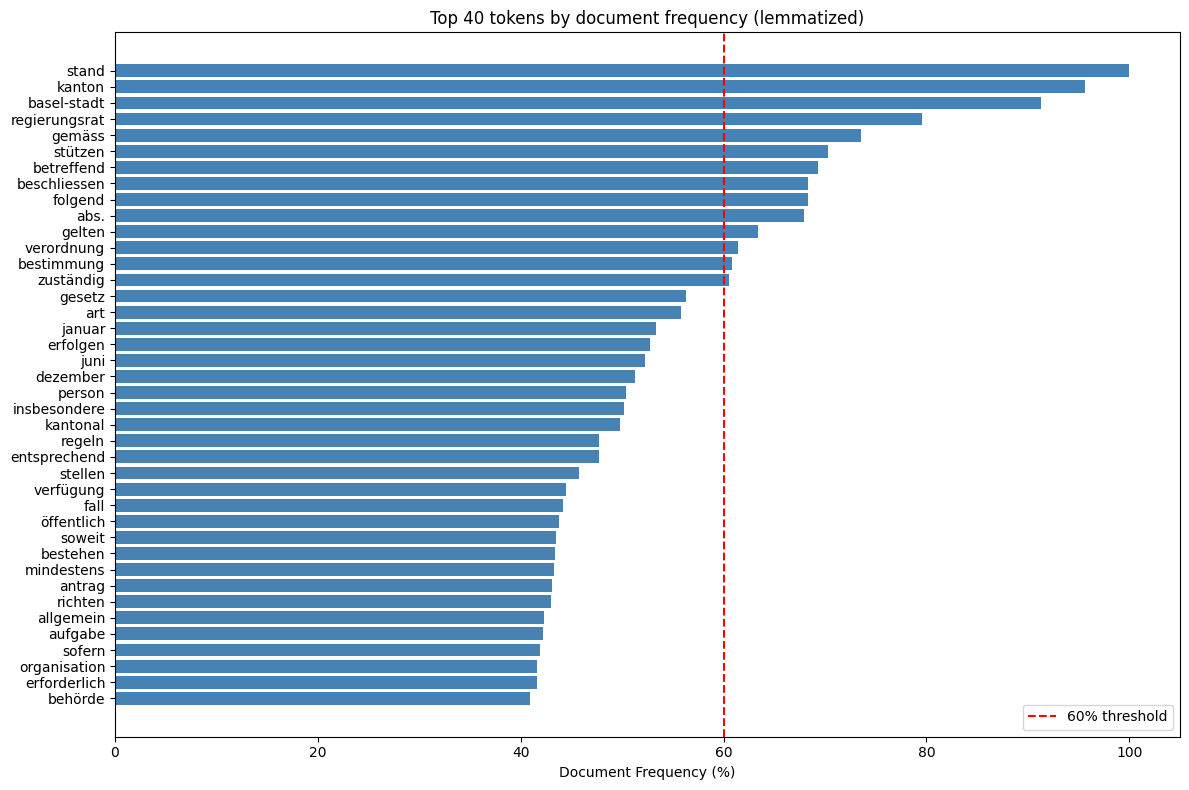

Figure saved.


In [3]:
top_n = 40
top = df_freq.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top["token"][::-1], top["doc_freq_pct"][::-1], color="steelblue")
ax.axvline(x=60, color="red", linestyle="--", label="60% threshold")
ax.set_xlabel("Document Frequency (%)")
ax.set_title(f"Top {top_n} tokens by document frequency (lemmatized)")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/01_3_token_frequency.png", dpi=150)
plt.show()
print("Figure saved.")

## 4. Define Legal Stopword List

Based on the frequency analysis above and legal domain expertise, the following tokens are classified as boilerplate — they appear across virtually all laws regardless of topic and carry no discriminating semantic signal.

**Edit this list** based on what you see in the frequency table above.

In [4]:
LEGAL_STOPWORDS = {
    # Structural / meta references
    "artikel", "absatz", "ziffer", "buchstabe", "satz", "litera",
    "alinea", "anhang", "fussnote",

    # Generic legal action verbs
    "gelten", "bestimmen", "regeln", "festlegen", "vorsehen", "anwenden",
    "aufheben", "ersetzen", "ergänzen", "ändern", "treten", "kraft",
    "inkrafttreten", "erfolgen", "erfolgt", "sicherstellen", "ermächtigen",

    # Generic legal nouns
    "gesetz", "verordnung", "erlass", "erlas", "bestimmung", "regelung", "vorschrift",
    "gesetzessammlung", "rechtsgrundlage", "rechtsvorschrift",

    # Jurisdiction / authority boilerplate
    "kanton", "basel-stadt", "regierungsrat", "grosser", "rat", "grossrat",
    "regierung", "verwaltung", "behörde", "departement", "amt", "kantonal",
    "basler", "riehen", "interkantonal", "bundesrecht", "amtsdauer", "organ",

    # Date / version boilerplate
    "stand", "januar", "februar", "märz", "april", "mai", "juni",
    "juli", "august", "september", "oktober", "november", "dezember",
    "datum", "jahr",

    # Function words / generic modal/procedural expressions
    "gemäss", "stützen", "betreffend", "beschliessen", "folgend", "abs.",
    "zuständig", "art", "person", "entsprechend", "stellen", "verfügung", "fall",
    "öffentlich", "soweit", "bestehen", "mindestens", "antrag", "richten", "allgemein",
    "aufgabe", "sofern", "organisation", "erforderlich", "entscheiden", "führen", "rahmen",
    "bzw.", "verfahren", "kosten", "fest", "bleiben", "schriftlich", "zweck", "ii.", "besonderer",
    "insbesondere", "pro", "erheben", "aufgrund", "setzen", "änderung", "legen", "basel", "basel-landschaft",
    "massnahmen", "iii.", "verpflichten", "nehmen", "sinn", "betragen", "zeitpunkt", "vorbehalt", "notwendig",
    "leistung", "übrig", "regel", "schweizerisch", "stehen", "einzeln", "zuständigkeit",
    "bundesgesetz", "durchführung", "grund", "lit", "jährlich", "allfällig", "voraussetzung", "angemessen",
    "bereich", "innerhalb", "gebühr", "iv.", "mitglied", "verlangen", "vollzug", "grundsatz", "publizieren",
    "erfüllen", "betrieb", "monat", "stelle", "zusätzlich", "gesuch", "erteilen", "erhalten", "anwendung",
    "jeweils", "vereinbarung", "anspruch", "gleich", "anderer", "enthalten", "dauer", "gesetzlich", "gemeinde", "bewilligung",
    "tragen", "tätigkeit", "erlassen", "genehmigung", "bezeichnen", "einreichen", "bisherig", "berücksichtigen", "höhe", "gegenstand",
    "liegen", "interesse", "rechnung", "bestehend", "verhältnis", "form", "verfügen", "übertragen", "gewähren", "entsprechen",
    "aufsicht", "finden", "entscheid", "durchführen", "frist", "ausnahme", "einhaltung", "gemeinsam", "treffen", "bericht",
    "geeignet", "nr.", "massgebend", "wählen", "ablauf", "schlussbestimmung", "kenntnis", "sorge", "angabe",
    "bund", "übernehmen", "abschluss", "betroffen", "direkt", "jeweilig", "privat", "geltend", "geltungsbereich", "erstellen",
    "bestimmt", "ausserhalb", "neu", "sorgen", "pflicht", "bezug", "inneren", "umfang", "spätestens", "melden",
    "übergangsbestimmung", "maximal", "erfüllung", "folgen", "geben", "hoch", "erlässen", "erlässt", "leitung", "prüfung",
    "leisten", "namentlich", "vertrag", "bedürfen", "eidgenössisch", "recht", "aufhebung", "höchstens", "vorbehalten",
    "fr.", "zusammenhang", "auftrag", "technisch", "verantwortlich", "unterliegen", "wahl", "mehrere", "kontrolle",
    "fallen", "lassen", "beginn", "berücksichtigung", "wirksamkeit", "vornehmen", "zulässig", "begründet",
    "vertreten", "beziehen", "prüfen", "informieren", "grundsätzlich", "zustimmung", "dienen", "vorliegen", "verwenden",
    "weise", "obliegen", "überprüfen", "ordentlich", "persönlich", "bedingung", "berechtigen", "bilden", "grundlage",
    "kommission", "sinngemäss", "beantragen", "unterlage", "sämtlicher", "erbringen", "genannt", "jederzeit", "festgelegt",
    "unterstehen", "präsident", "vereinbaren", "abschließen", "anordnung", "reglement", "anerkannt", "wesentlich",
    "möglichkeit", "verwendung", "auskunft", "vorgesehen", "bewilligen", "massgabe", "inhalt", "aufwand", "vertretung",
    "unterstützen", "ausführung", "frei", "chf", "bedarf", "beurteilung", "speziell", "ausnehmen", "anforderung", "frage",
    "partei", "anwendbar", "nötig", "gesamt", "erreichen", "letzter", "stunde", "begründen", "anordnen", "genehmigen",
    "betrag", "fördern", "gewährleisten", "bezüglich", "sofort", "erklären", "weisung", "regelmässig", "aufnahme",
    "entscheide", "unmittelbar", "beteiligen", "einschliesslich", "betreffen", "laufend", "wohnsitz", "ausführungsbestimmung",
    "falls", "ausschliesslich", "umfasst", "unverzüglich", "übergang", "rechtzeitig", "nachfolgend", "beschluß",
    "anzahl", "vollständig", "mittels", "öffentlich-rechtlich", "geschäft", "wichtig", "koordination", "einzelfall",
    "berechnung", "verweis", "ergeben", "beschluss", "schweiz", "erstellung", "aufnehmen", "kalenderjahr", "bringen",
    "ort", "amtlich", "dienst", "rechtsmittel", "gericht", "leiten", "unentgeltlich", "vii", "einsetzen",
    "ausserordentlich", "richtlinie", "rekurs", "entrichten", "unabhängig", "periodisch", "einhalten", "ausrichten",
    "erläuterung", "organe", "sitz", "entstehen", "kündigung", "jeder", "abteilung", "mitteilen", "berechnen",
    "einzelheit", "bezeichnet", "unterhalt", "staatlich", "ebenfalls", "wirksam", "last", "anpassung",
    "erteilung", "vorlegen", "gleichzeitig", "einvernehmen", "teilweise", "ziff", "schlussbestimmunge", "zudem",
    "organisationsgesetz", "vorgabe", "sache", "gewährung", "teil", "sitzung", "zusammensetzung", "kompetenz", "kündigen",
    "betreiben", "voraus", "streitigkeit", "vertreter", "mitwirkung", "beurteilen", "vorhanden", "einsichtnahme", "abweichend",
    "halten", "abgabe", "unterbreiten", "selbständig", "ausrichtung", "erhebung", "name", "meldung", "wobei", "vorliegend", "befugnis",
    "nutzung", "festlegung", "gleichzustellen", "angesichts", "rechtsnatur", "zukünftig", "verzichten", "per", "entfernen", "publikation",
    "amtsblatt",
    
    # Added after rank 31-100 inspection
    "innert", "weder", "sowohl", "gegebenenfalls", "ausdrücklich", "vorgängig",
    "mitteilung", "infolge", "ausschließen",
}


## 5. Apply Legal Stopword Filter

In [5]:
def remove_legal_stopwords(text):
    tokens = str(text).split()
    return " ".join(t for t in tokens if t not in LEGAL_STOPWORDS)

df["text_clean"] = df["text_lemmatized"].apply(remove_legal_stopwords)

# Report reduction
before = df["text_lemmatized"].str.split().str.len().mean()
after  = df["text_clean"].str.split().str.len().mean()
print(f"Avg tokens before legal stopword removal: {before:.0f}")
print(f"Avg tokens after legal stopword removal:  {after:.0f}")
print(f"Additional reduction: {(1 - after/before):.1%}")

Avg tokens before legal stopword removal: 675
Avg tokens after legal stopword removal:  414
Additional reduction: 38.6%


## 6. Inspect a Sample

In [6]:
idx = 0
print("=== LEMMATIZED ===")
print(df["text_lemmatized"].iloc[idx][:300])
print("\n=== AFTER LEGAL STOPWORDS ===")
print(df["text_clean"].iloc[idx][:300])

=== LEMMATIZED ===
spitäler entfernung spitalliste gesetzessammlung november stand januar spitalliste kanton basel-landschaft basel-stadt gesetzessammlung aufnehmen spitalliste wesentlich inhalt leistungsauftrag öffentlich öffentlich register gleichzustellen angesichts rechtsnatur spitalliste zukünftig aufnahme gesetz

=== AFTER LEGAL STOPWORDS ===
spitäler entfernung spitalliste spitalliste spitalliste leistungsauftrag register spitalliste spitalliste entfernt spitalliste spitalliste administrativ vereinfachen publizität transparenzfunktion spitalliste aufschalt webseit ausreichend spitallisten akutsomatik rehabilitation psychiatrie webseite 


## 7. Re-check Frequency on Clean Text

Verify that the boilerplate tokens are gone and inspect what remains at the top.

In [7]:
doc_freq_clean = defaultdict(int)
for text in df["text_clean"]:
    for token in set(str(text).split()):
        doc_freq_clean[token] += 1

df_freq_clean = pd.DataFrame([
    {"token": token, "doc_freq": count, "doc_freq_pct": count / n_docs * 100}
    for token, count in doc_freq_clean.items()
]).sort_values("doc_freq", ascending=False).reset_index(drop=True)

print("Top 30 tokens after legal stopword removal:")
df_freq_clean.head(30)

Top 30 tokens after legal stopword removal:


,token,doc_freq,doc_freq_pct
0,arbeit,177,24.147340
1,beitrag,175,23.874488
2,information,172,23.465211
3,zusammenarbeit,155,21.145975
4,entschädigung,154,21.009550
5,einrichtung,148,20.190996
6,bau,138,18.826739
7,gebiet,137,18.690314
8,stadt,131,17.871760
9,anlage,129,17.598909


## 7b. Inspect Ranks 30–100

Verify that tokens just below the top-30 threshold are semantically meaningful. If boilerplate is still visible, add it to `LEGAL_STOPWORDS` in Step 4 and re-run.

In [8]:
df_freq_clean.iloc[30:100].reset_index(drop=True)

,token,doc_freq,doc_freq_pct
0,beruflich,85,11.596180
1,ausübung,85,11.596180
2,verkehr,84,11.459754
3,schule,84,11.459754
4,ziel,84,11.459754
...,...,...,...
65,handeln,74,10.095498
66,entwicklung,74,10.095498
67,lang,74,10.095498
68,ausland,74,10.095498


## 8. Iterate if Needed

If the table above still shows boilerplate tokens, add them to `LEGAL_STOPWORDS` in Step 4 and re-run Steps 5–7. Repeat until the top tokens are semantically meaningful (domain-specific legal vocabulary).

## 9. Persist

In [9]:
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"Saved {len(df)} records to {CLEAN_DATA_PATH}")

Saved 733 records to ../data/processed/sgbs_clean.csv


## 10. Summary

**What we did:**
- Computed document frequency for all lemmatized tokens
- Identified legal boilerplate vocabulary using frequency analysis and domain expertise
- Curated a `LEGAL_STOPWORDS` list and applied it to produce `text_clean`
- Persisted as `data/processed/sgbs_clean.csv`

**Next step:** `02_feature_engineering.ipynb` — convert `text_clean` into numerical vectors (TF-IDF or embeddings).